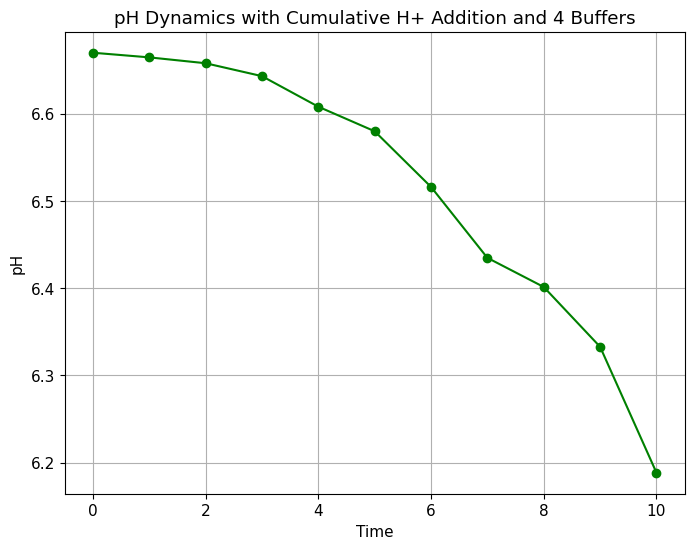

,0
0,6.670000
1,6.664675
2,6.657951
3,6.643153
4,6.608111
5,6.579930
6,6.516100
7,6.434740
8,6.401326
9,6.332712


In [25]:
import numpy as np
from scipy.optimize import fsolve
import matplotlib.pyplot as plt
import pandas as pd

## Global functions, called later.
def calculate_initial_concentrations(hepes_pka, hepes_conc, mg_pka, mg_conc,
                                     new_pka, new_conc, ntp_pka, ntp_conc, target_ph):
    def eqs(variables):
        hepes_a_minus, mg_a_minus, new_a_minus, ntp_a_minus, h_conc = variables # Variables defined here to simplify, but can be included in the definition as well
        
        # Mass balance for Conj base and acid
        hepes_ha = hepes_conc - hepes_a_minus
        mg_ha = mg_conc - mg_a_minus
        new_ha = new_conc - new_a_minus
        ntp_ha = ntp_conc - ntp_a_minus

        #Definining Ka as it's easier to solver later
        ka_hepes = 10**(-hepes_pka)
        ka_mg = 10**(-mg_pka)
        ka_new = 10**(-new_pka)
        ka_ntp = 10**(-ntp_pka)

        #return statement here should sum to 0. Treat - as an = sign
        return [
            ka_hepes - (h_conc * hepes_a_minus / hepes_ha),
            ka_mg - (h_conc * mg_a_minus / mg_ha),
            ka_new - (h_conc * new_a_minus / new_ha),
            ka_ntp - (h_conc * ntp_a_minus / ntp_ha),
            h_conc - 10**(-target_ph)
        ]
    #solve for conj base explicitly for each individual species
    def initial_guess_for_species(pKa, conc, pH):
        return conc / (1 + 10**(pKa - pH))

    guess = [
        initial_guess_for_species(hepes_pka, hepes_conc, target_ph),
        initial_guess_for_species(mg_pka, mg_conc, target_ph),
        initial_guess_for_species(new_pka, new_conc, target_ph),
        initial_guess_for_species(ntp_pka, ntp_conc, target_ph),
        10**(-target_ph)
    ]
    #solution object using fsolve where eqns are a function and initial guess is the individual conjugate base concentrations. Now we have initial 
    # concentrations for all species 
    sol = fsolve(eqs, guess)
    hepes_a, mg_a, new_a, ntp_a, h = sol
    #returs conj base and acid concentrations for species and H+ ion concentration
    return (
        hepes_conc - hepes_a, hepes_a,
        mg_conc - mg_a, mg_a,
        new_conc - new_a, new_a,
        ntp_conc - ntp_a, ntp_a,
        h
    )
#Does the same thing for ther rest of the reaction
def simulate_ph_dynamics(hepes_pka, hepes_conc, mg_pka, mg_conc,
                         new_pka, new_conc, ntp_pka, ntp_conc,
                         h_cumulative_addition, total_time, time_step, target_ph):
    
    (hepes_ha_init, hepes_a_init,
     mg_ha_init, mg_a_init,
     new_ha_init, new_a_init,
     ntp_ha_init, ntp_a_init,
     h_init) = calculate_initial_concentrations(
        hepes_pka, hepes_conc, mg_pka, mg_conc,
        new_pka, new_conc, ntp_pka, ntp_conc, target_ph
    )
    # Add 1 to include initial pH
    num_steps = int(total_time / time_step) + 1
    time_points = np.linspace(0, total_time, num_steps)
    ph_values = [target_ph]

    initial_proton_balance = (
        h_init +
        (hepes_a_init - hepes_ha_init) +
        (mg_a_init - mg_ha_init) +
        (new_a_init - new_ha_init) +
        (ntp_a_init - ntp_ha_init)
    )

    ##loop to go through cumulative H+ addition. calculated separately in excel
    for step in range(1, num_steps):
        h_added = h_cumulative_addition[step] if step < len(h_cumulative_addition) else h_cumulative_addition[-1]

        def dynamic_eqs(variables):
            hepes_ha, hepes_a, mg_ha, mg_a, new_ha, new_a, ntp_ha, ntp_a, h = variables

            return [
                hepes_ha + hepes_a - hepes_conc,
                mg_ha + mg_a - mg_conc,
                new_ha + new_a - new_conc,
                ntp_ha + ntp_a - ntp_conc,

                10**(-hepes_pka) - (h * hepes_a / hepes_ha),
                10**(-mg_pka) - (h * mg_a / mg_ha),
                10**(-new_pka) - (h * new_a / new_ha),
                10**(-ntp_pka) - (h * ntp_a / ntp_ha),

                
                h +
                (hepes_a - hepes_ha) +
                (mg_a - mg_ha) +
                (new_a - new_ha) +
                (ntp_a - ntp_ha) -
                (initial_proton_balance - h_added)
            ]

        if step == 1:
            initial_guess = [
                hepes_ha_init, hepes_a_init,
                mg_ha_init, mg_a_init,
                new_ha_init, new_a_init,
                ntp_ha_init, ntp_a_init,
                h_init
            ]
        else:
            initial_guess = solution

        solution = fsolve(dynamic_eqs, initial_guess)
        h_conc = max(solution[-1], 1e-20)
        ph_values.append(-np.log10(h_conc))

    return time_points, ph_values


#User inputs

hepes_pka = 7.3
hepes_conc = 0.04

mg_pka = 4.73
mg_conc = 0.042

new_pka = 7.2
new_conc = 0.064

ntp_pka = 6.95
ntp_conc = 0.008  

# Manually calculated using measured time series yield values.

h_cumulative_addition = [0.000275928,
0.000481406,
0.001084925,
0.002396071,
0.005408185,
0.007736156,
0.012702856,
0.018439806,
0.020612785,
0.024763077,
0.032281499


]


total_time = 10 # Number of time steps, not unit time measurements
time_step = 1
target_ph = 6.67


#Running the simulation

time_points, ph_values = simulate_ph_dynamics(
    hepes_pka, hepes_conc,
    mg_pka, mg_conc,
    new_pka, new_conc,
    ntp_pka, ntp_conc,
    h_cumulative_addition,
    total_time, time_step, target_ph
)

# plotting time

plt.figure(figsize=(8, 6))
plt.plot(time_points, ph_values, marker='o', color='green')
plt.xlabel('Time')
plt.ylabel('pH')
plt.title('pH Dynamics with Cumulative H+ Addition and 4 Buffers')
plt.grid(True)
plt.show()

df = pd.DataFrame(ph_values)
df.head(20)

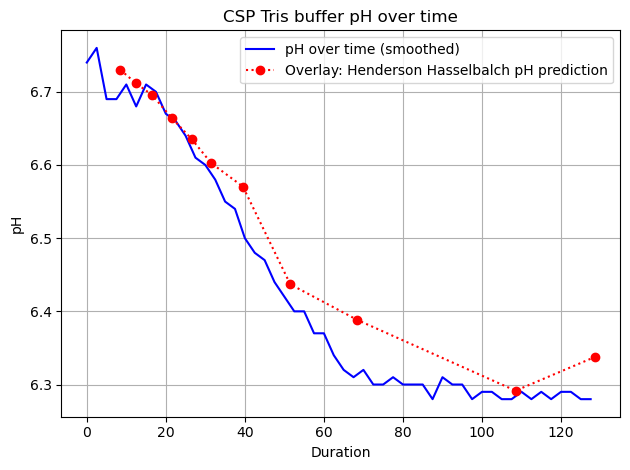

In [3]:
import pandas as pd
import matplotlib.pyplot as plt


data = pd.read_excel('CSP Tris.xlsx')


downsampled = data.iloc[::5]

plt.plot(downsampled['Duration'], downsampled['pH'], color='blue', linewidth=1.5, label='pH over time (smoothed)')


ph_egfp = [6.73, 6.7114579463011514, 6.695755525330327, 6.664282834491861, 6.635617105506875, 6.6024343720876875, 6.5704826127051525, 6.436901162672016, 6.388147737917416, 6.291570905161747, 6.33748221796747]
times = [8.5, 12.5, 16.5, 21.5, 26.5, 31.5, 39.5, 51.5, 68.5, 108.5, 128.5]


plt.plot(times, ph_egfp, linestyle=':', marker='o', color='red', label='Overlay: Henderson Hasselbalch pH prediction')


plt.xlabel('Duration')
plt.ylabel('pH')
plt.title('CSP Tris buffer pH over time')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

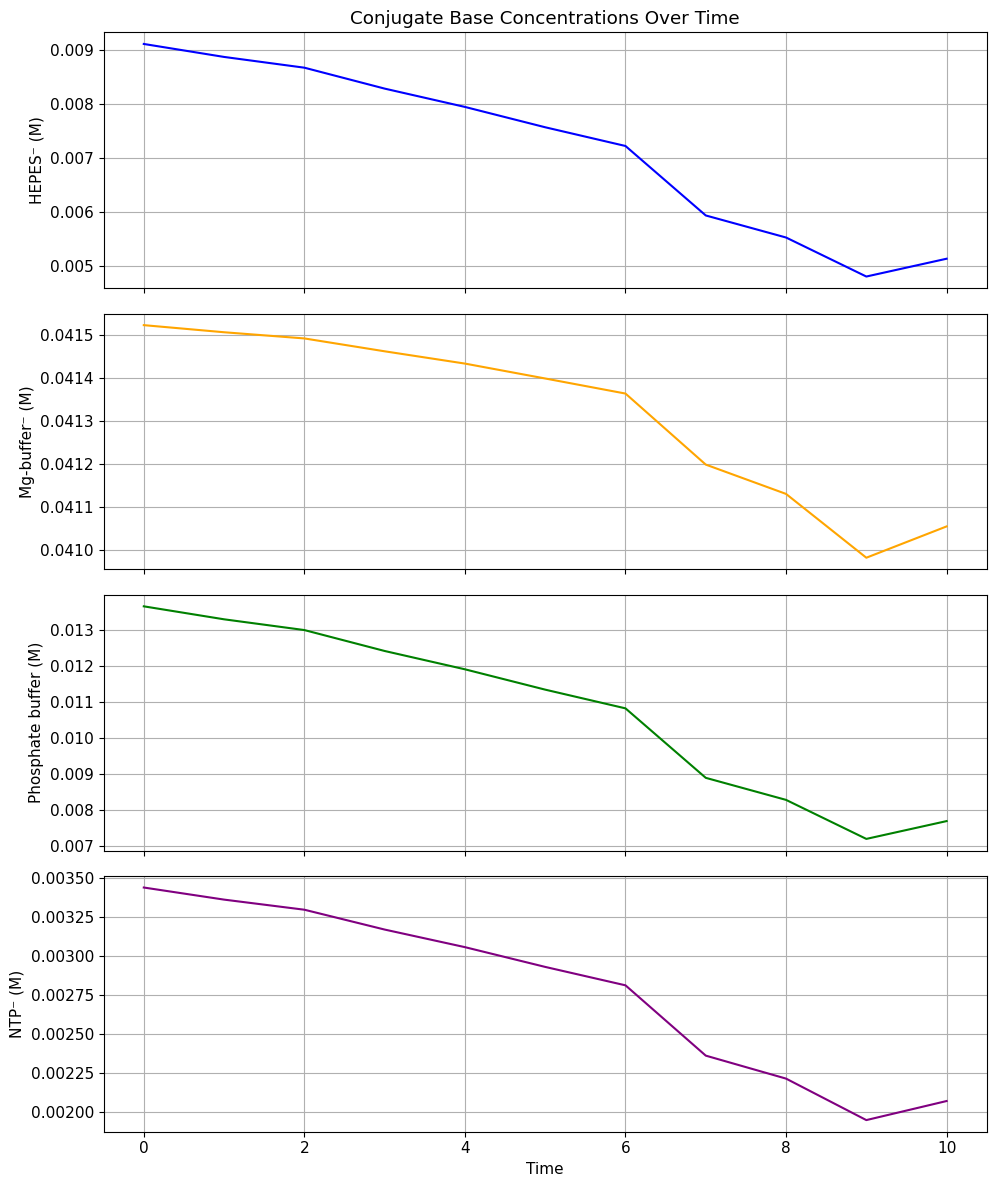

In [21]:
import numpy as np
from scipy.optimize import fsolve
import matplotlib.pyplot as plt
import pandas as pd

def calculate_initial_concentrations(hepes_pka, hepes_conc, mg_pka, mg_conc,
                                     new_pka, new_conc, ntp_pka, ntp_conc, target_ph):
    def eqs(variables):
        hepes_a_minus, mg_a_minus, new_a_minus, ntp_a_minus, h_conc = variables

        hepes_ha = hepes_conc - hepes_a_minus
        mg_ha = mg_conc - mg_a_minus
        new_ha = new_conc - new_a_minus
        ntp_ha = ntp_conc - ntp_a_minus

        ka_hepes = 10**(-hepes_pka)
        ka_mg = 10**(-mg_pka)
        ka_new = 10**(-new_pka)
        ka_ntp = 10**(-ntp_pka)

        return [
            ka_hepes - (h_conc * hepes_a_minus / hepes_ha),
            ka_mg - (h_conc * mg_a_minus / mg_ha),
            ka_new - (h_conc * new_a_minus / new_ha),
            ka_ntp - (h_conc * ntp_a_minus / ntp_ha),
            h_conc - 10**(-target_ph)
        ]

    def initial_guess_for_species(pKa, conc, pH):
        return conc / (1 + 10**(pKa - pH))

    guess = [
        initial_guess_for_species(hepes_pka, hepes_conc, target_ph),
        initial_guess_for_species(mg_pka, mg_conc, target_ph),
        initial_guess_for_species(new_pka, new_conc, target_ph),
        initial_guess_for_species(ntp_pka, ntp_conc, target_ph),
        10**(-target_ph)
    ]

    sol = fsolve(eqs, guess)
    hepes_a, mg_a, new_a, ntp_a, h = sol

    return (
        hepes_conc - hepes_a, hepes_a,
        mg_conc - mg_a, mg_a,
        new_conc - new_a, new_a,
        ntp_conc - ntp_a, ntp_a,
        h
    )

def simulate_ph_dynamics(hepes_pka, hepes_conc, mg_pka, mg_conc,
                         new_pka, new_conc, ntp_pka, ntp_conc,
                         h_cumulative_addition, total_time, time_step, target_ph):
    
    (hepes_ha_init, hepes_a_init,
     mg_ha_init, mg_a_init,
     new_ha_init, new_a_init,
     ntp_ha_init, ntp_a_init,
     h_init) = calculate_initial_concentrations(
        hepes_pka, hepes_conc, mg_pka, mg_conc,
        new_pka, new_conc, ntp_pka, ntp_conc, target_ph
    )

    num_steps = int(total_time / time_step) + 1
    time_points = np.linspace(0, total_time, num_steps)
    ph_values = [target_ph]

    hepes_a_vals = [hepes_a_init]
    mg_a_vals = [mg_a_init]
    new_a_vals = [new_a_init]
    ntp_a_vals = [ntp_a_init]

    initial_proton_balance = (
        h_init +
        (hepes_a_init - hepes_ha_init) +
        (mg_a_init - mg_ha_init) +
        (new_a_init - new_ha_init) +
        (ntp_a_init - ntp_ha_init)
    )

    for step in range(1, num_steps):
        h_added = h_cumulative_addition[step] if step < len(h_cumulative_addition) else h_cumulative_addition[-1]

        def dynamic_eqs(variables):
            hepes_ha, hepes_a, mg_ha, mg_a, new_ha, new_a, ntp_ha, ntp_a, h = variables

            return [
                hepes_ha + hepes_a - hepes_conc,
                mg_ha + mg_a - mg_conc,
                new_ha + new_a - new_conc,
                ntp_ha + ntp_a - ntp_conc,

                10**(-hepes_pka) - (h * hepes_a / hepes_ha),
                10**(-mg_pka) - (h * mg_a / mg_ha),
                10**(-new_pka) - (h * new_a / new_ha),
                10**(-ntp_pka) - (h * ntp_a / ntp_ha),

                h +
                (hepes_a - hepes_ha) +
                (mg_a - mg_ha) +
                (new_a - new_ha) +
                (ntp_a - ntp_ha) -
                (initial_proton_balance - h_added)
            ]

        if step == 1:
            initial_guess = [
                hepes_ha_init, hepes_a_init,
                mg_ha_init, mg_a_init,
                new_ha_init, new_a_init,
                ntp_ha_init, ntp_a_init,
                h_init
            ]
        else:
            initial_guess = solution

        solution = fsolve(dynamic_eqs, initial_guess)
        hepes_a, mg_a, new_a, ntp_a, h_conc = solution[1], solution[3], solution[5], solution[7], solution[-1]

        hepes_a_vals.append(hepes_a)
        mg_a_vals.append(mg_a)
        new_a_vals.append(new_a)
        ntp_a_vals.append(ntp_a)

        ph_values.append(-np.log10(max(h_conc, 1e-20)))

    return time_points, ph_values, hepes_a_vals, mg_a_vals, new_a_vals, ntp_a_vals

# ======= Parameters =======

hepes_pka = 7.2
hepes_conc = 0.04

mg_pka = 4.73
mg_conc = 0.042

new_pka = 7.2
new_conc = 0.06

ntp_pka = 6.95
ntp_conc = 0.01

h_cumulative_addition = [0.00029848,
0.001392257,
0.002548868,
0.004805147,
0.006788475,
0.008999587,
0.011043788,
0.018725741,
0.021203918,
0.025655601,
0.023611401]

total_time = 10
time_step = 1
target_ph = 6.67

# ======= Run simulation =======

(time_points, ph_values,
 hepes_a_vals, mg_a_vals, new_a_vals, ntp_a_vals) = simulate_ph_dynamics(
    hepes_pka, hepes_conc,
    mg_pka, mg_conc,
    new_pka, new_conc,
    ntp_pka, ntp_conc,
    h_cumulative_addition,
    total_time, time_step, target_ph
)


fig, axs = plt.subplots(4, 1, figsize=(10, 12), sharex=True)

axs[0].plot(time_points, hepes_a_vals, color='blue')
axs[0].set_ylabel('HEPES⁻ (M)')
axs[0].set_title('Conjugate Base Concentrations Over Time')
axs[0].grid(True)

axs[1].plot(time_points, mg_a_vals, color='orange')
axs[1].set_ylabel('Mg-buffer⁻ (M)')
axs[1].grid(True)

axs[2].plot(time_points, new_a_vals, color='green')
axs[2].set_ylabel('Phosphate buffer (M)')
axs[2].grid(True)

axs[3].plot(time_points, ntp_a_vals, color='purple')
axs[3].set_ylabel('NTP⁻ (M)')
axs[3].set_xlabel('Time')
axs[3].grid(True)

plt.tight_layout()
plt.show()


      Time  A_remaining_mM  U_remaining_mM  C_remaining_mM  G_remaining_mM
281  140.5             0.0             0.0             0.0             0.0
282  141.0             0.0             0.0             0.0             0.0
283  141.5             0.0             0.0             0.0             0.0
284  142.0             0.0             0.0             0.0             0.0
285  142.5             0.0             0.0             0.0             0.0
286  143.0             0.0             0.0             0.0             0.0
287  143.5             0.0             0.0             0.0             0.0
288  144.0             0.0             0.0             0.0             0.0
289  144.5             0.0             0.0             0.0             0.0
290  145.0             0.0             0.0             0.0             0.0
291  145.5             0.0             0.0             0.0             0.0
292  146.0             0.0             0.0             0.0             0.0
293  146.5             0.

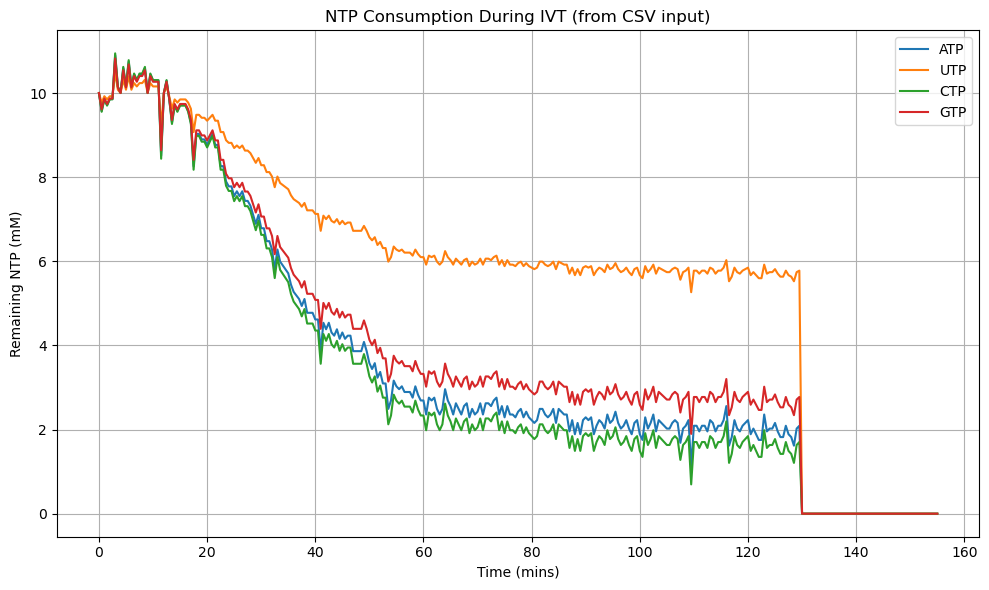

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def calculate_ntp_consumption_from_csv(
    csv_path,
    mRNA_length_nt,
    ntp_composition,
    initial_ntp_concentration_mM
):

    df_input = pd.read_excel(csv_file, sheet_name= 'Sheet1')
    

    time_points = df_input['Time'].values
    mRNA_profile_mg = df_input['eGFP Tris 1'].values

    avg_nt_mw = 340  # g/mol
    ntps = ['A', 'U', 'C', 'G']

    ntp_remaining = {ntp: [initial_ntp_concentration_mM[ntp]] for ntp in ntps}
    
    for i in range(1, len(time_points)):
        delta_mRNA_mg = mRNA_profile_mg[i] - mRNA_profile_mg[i-1]
        moles_mRNA = (delta_mRNA_mg ) / (mRNA_length_nt * avg_nt_mw)

        for ntp in ntps:
            used_mol = moles_mRNA * mRNA_length_nt * ntp_composition[ntp]
            used_mM = used_mol * 1e3  # mol/L → mmol/L
            remaining = ntp_remaining[ntp][-1] - used_mM
            ntp_remaining[ntp].append(max(0, remaining))

    # Compile results
    df_output = pd.DataFrame({'Time': time_points})
    for ntp in ntps:
        df_output[f'{ntp}_remaining_mM'] = ntp_remaining[ntp]

    return df_output


csv_file = 'HH mRNA pred.xlsx' 
mRNA_length = 930  # in nt
ntp_composition = {'A': 0.2860215054, 'U': 0.152688172, 'C': 0.3, 'G':0.2612903226 }
initial_ntp_conc = {'A': 10, 'U': 10, 'C': 10, 'G': 10}  # in mM

			
df = calculate_ntp_consumption_from_csv(
    csv_file,
    mRNA_length,
    ntp_composition,
    initial_ntp_conc
)

print(df.tail(30))
df.to_clipboard(index=False)

# Plot
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
for ntp in ['A', 'U', 'C', 'G']:
    plt.plot(df['Time'], df[f'{ntp}_remaining_mM'], label=f'{ntp}TP')

plt.xlabel("Time (mins)")
plt.ylabel("Remaining NTP (mM)")
plt.title("NTP Consumption During IVT (from CSV input)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

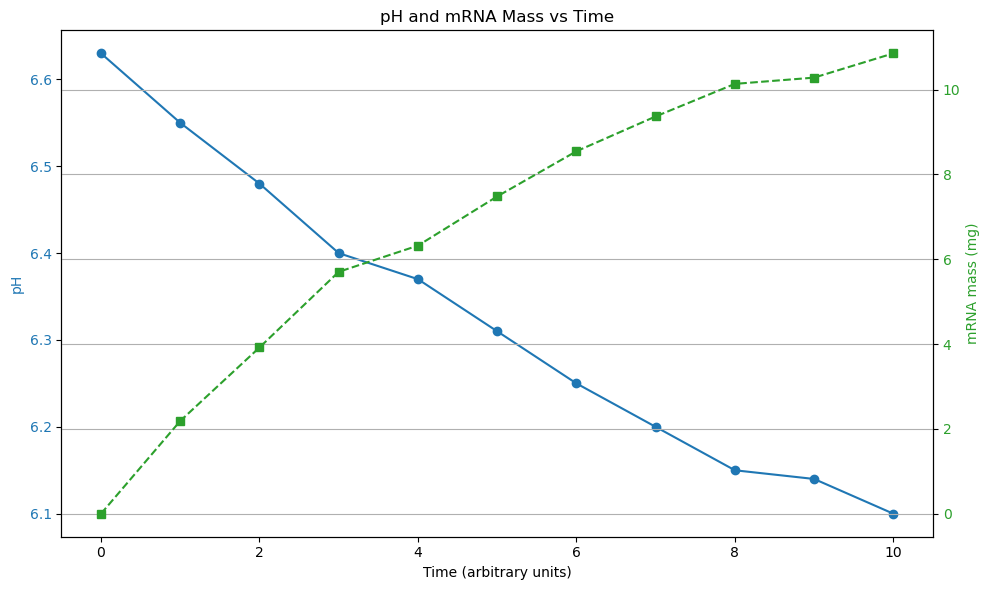

Time	pH	H+ added (mol)	mRNA mass (mg)
0	6.63	0.0000e+00	0.000000
1	6.55	6.4196e-03	2.186967
2	6.48	1.1504e-02	3.919042
3	6.40	1.6740e-02	5.702669
4	6.37	1.8554e-02	6.320922
5	6.31	2.1958e-02	7.480480
6	6.25	2.5083e-02	8.544988
7	6.20	2.7494e-02	9.366338
8	6.15	2.9747e-02	10.133994
9	6.14	3.0181e-02	10.281589
10	6.10	3.1860e-02	10.853728


In [3]:
import numpy as np
from scipy.optimize import fsolve
import matplotlib.pyplot as plt

#Version for deployment 

PROTONS_PER_MRNA = 930
MRNA_MW_G_PER_MOL = 316_822  # g/mol
VOLUME_LITERS = 0.001  # 1 mL solution


# Buffer parameters
hepes_pka = 7.3
hepes_conc = 0.04

mg_pka = 4.73
mg_conc = 0.042

new_pka = 7.2
new_conc = 0.064

ntp_pka = 6.95
ntp_conc = 0.006

# Constants for mRNA conversion
PROTONS_PER_MRNA = 930
MRNA_MW_G_PER_MOL = 316822
VOLUME_LITERS = 0.001  # 

def total_proton_balance(ph):
    """Calculate total proton balance at a given pH."""
    def equations(vars):
        hepes_a, mg_a, new_a, ntp_a = vars
        hepes_ha = hepes_conc - hepes_a
        mg_ha = mg_conc - mg_a
        new_ha = new_conc - new_a
        ntp_ha = ntp_conc - ntp_a
        h = 10 ** -ph

        return [
            (h * hepes_a / hepes_ha) - 10**-hepes_pka,
            (h * mg_a / mg_ha) - 10**-mg_pka,
            (h * new_a / new_ha) - 10**-new_pka,
            (h * ntp_a / ntp_ha) - 10**-ntp_pka,
        ]

    def initial_guess(pKa, conc, pH):
        return conc / (1 + 10 ** (pKa - pH))

    guess = [
        initial_guess(hepes_pka, hepes_conc, ph),
        initial_guess(mg_pka, mg_conc, ph),
        initial_guess(new_pka, new_conc, ph),
        initial_guess(ntp_pka, ntp_conc, ph)
    ]

    sol = fsolve(equations, guess)
    hepes_a, mg_a, new_a, ntp_a = sol
    hepes_ha = hepes_conc - hepes_a
    mg_ha = mg_conc - mg_a
    new_ha = new_conc - new_a
    ntp_ha = ntp_conc - ntp_a
    h = 10 ** -ph

    total_protons = (
        h +
        (hepes_a - hepes_ha) +
        (mg_a - mg_ha) +
        (new_a - new_ha) +
        (ntp_a - ntp_ha)
    )
    return total_protons

def initial_guess(pKa, conc, pH):
    return conc / (1 + 10 ** (pKa - pH))

# Example pH series (replace with your real data)
ph_series = [6.63, 6.55, 6.48, 6.4 , 6.37, 6.31, 6.25, 6.20, 6.15, 6.14, 6.1]
time_series = list(range(len(ph_series)))

# Calculate baseline proton balance at initial pH
baseline_ph = ph_series[0]
baseline_protons = total_proton_balance(baseline_ph)

# Calculate cumulative H+ ions added at each pH point relative to baseline
h_plus_added = []
mrna_mass_mg = []

for ph in ph_series:
    current_protons = total_proton_balance(ph)
    delta_h = baseline_protons - current_protons  # positive means protons added
    h_plus_added.append(delta_h)

    # Convert protons added to mRNA molecules (moles)
    mrna_mol = delta_h / PROTONS_PER_MRNA

    # Convert moles to mass (mg)
    mrna_mass = mrna_mol * MRNA_MW_G_PER_MOL * 1000 * VOLUME_LITERS  # mg in 1 mL
    mrna_mass_mg.append(mrna_mass)

# Plotting
fig, ax1 = plt.subplots(figsize=(10, 6))

ax1.set_xlabel('Time (arbitrary units)')
ax1.set_ylabel('pH', color='tab:blue')
ax1.plot(time_series, ph_series, 'o-', color='tab:blue', label='pH')
ax1.tick_params(axis='y', labelcolor='tab:blue')

ax2 = ax1.twinx()
ax2.set_ylabel('mRNA mass (mg)', color='tab:green')
ax2.plot(time_series, mrna_mass_mg, 's--', color='tab:green', label='mRNA mass')
ax2.tick_params(axis='y', labelcolor='tab:green')

plt.title('pH and mRNA Mass vs Time')
fig.tight_layout()
plt.grid(True)
plt.show()

# Print out results
print("Time\tpH\tH+ added (mol)\tmRNA mass (mg)")
for t, ph, h, m in zip(time_series, ph_series, h_plus_added, mrna_mass_mg):
    print(f"{t}\t{ph:.2f}\t{h:.4e}\t{m:.6f}")


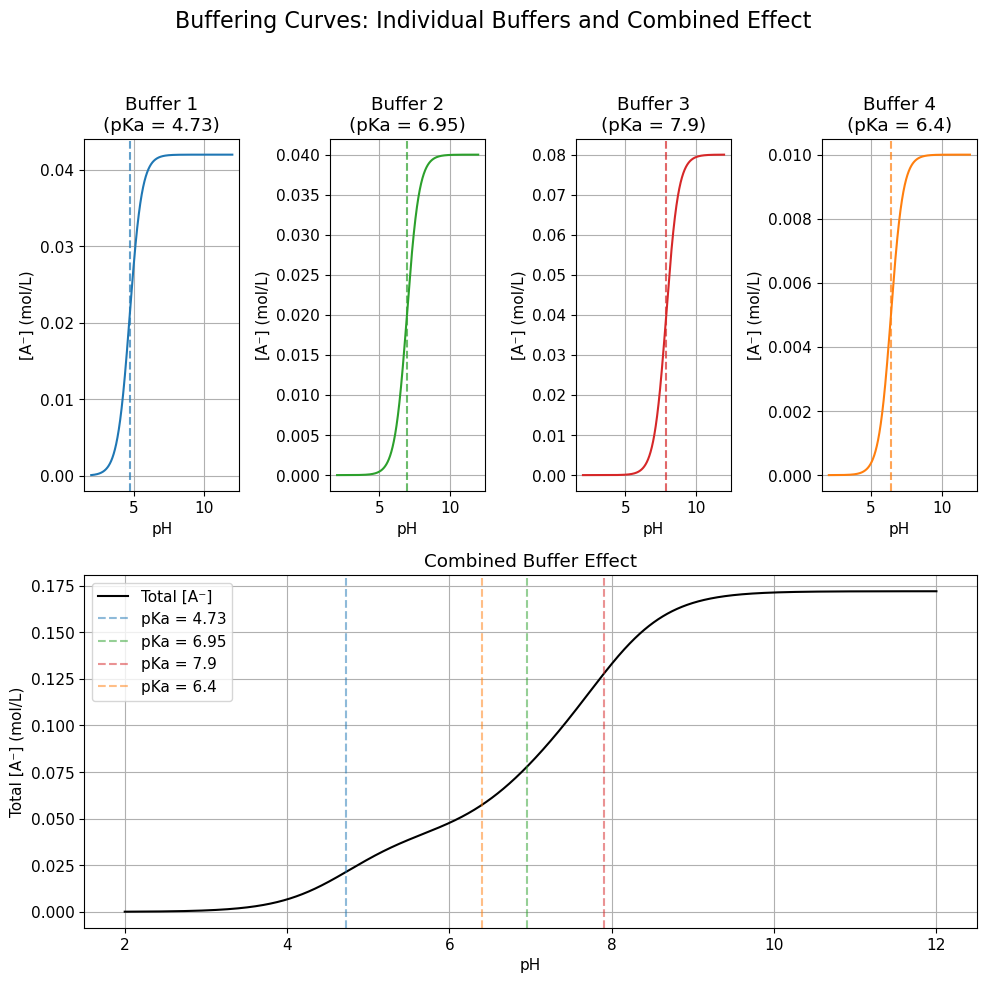

In [37]:
import numpy as np
import matplotlib.pyplot as plt

buffers = [
    (4.73, 0.042), 
    (6.95, 0.04),  
    (7.9,  0.08),
    (6.4, 0.01)]

pH_values = np.linspace(2, 12, 6000)
H_conc = 10**(-pH_values)

def individual_base_conc(pH, pKa, total_conc):
    Ka = 10**(-pKa)
    H = 10**(-pH)
    return total_conc * Ka / (Ka + H)


individual_A_curves = [individual_base_conc(pH_values, pKa, conc) for pKa, conc in buffers]


total_A = np.sum(individual_A_curves, axis=0)


fig = plt.figure(figsize=(10, 10))
gs = fig.add_gridspec(2, 4, height_ratios=[1, 1])

colors = ['tab:blue', 'tab:green', 'tab:red', 'tab:orange']

for i in range(4):
    ax = fig.add_subplot(gs[0, i])
    A_curve = individual_A_curves[i]
    pKa, _ = buffers[i]
    ax.plot(pH_values, A_curve, color=colors[i])
    ax.axvline(pKa, linestyle='--', color=colors[i], alpha=0.7)
    ax.set_title(f'Buffer {i+1}\n(pKa = {pKa})')
    ax.set_xlabel('pH')
    ax.set_ylabel('[A⁻] (mol/L)')
    ax.grid(True)

ax_combined = fig.add_subplot(gs[1, :])
ax_combined.plot(pH_values, total_A, label='Total [A⁻]', color='black')
for i, (pKa, _) in enumerate(buffers):
    ax_combined.axvline(pKa, linestyle='--', color=colors[i], alpha=0.5, label=f'pKa = {pKa}')
ax_combined.set_title('Combined Buffer Effect')
ax_combined.set_xlabel('pH')
ax_combined.set_ylabel('Total [A⁻] (mol/L)')
ax_combined.grid(True)
ax_combined.legend()

fig.suptitle('Buffering Curves: Individual Buffers and Combined Effect', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig('Buffering curves subplots - Tris.jpeg', )


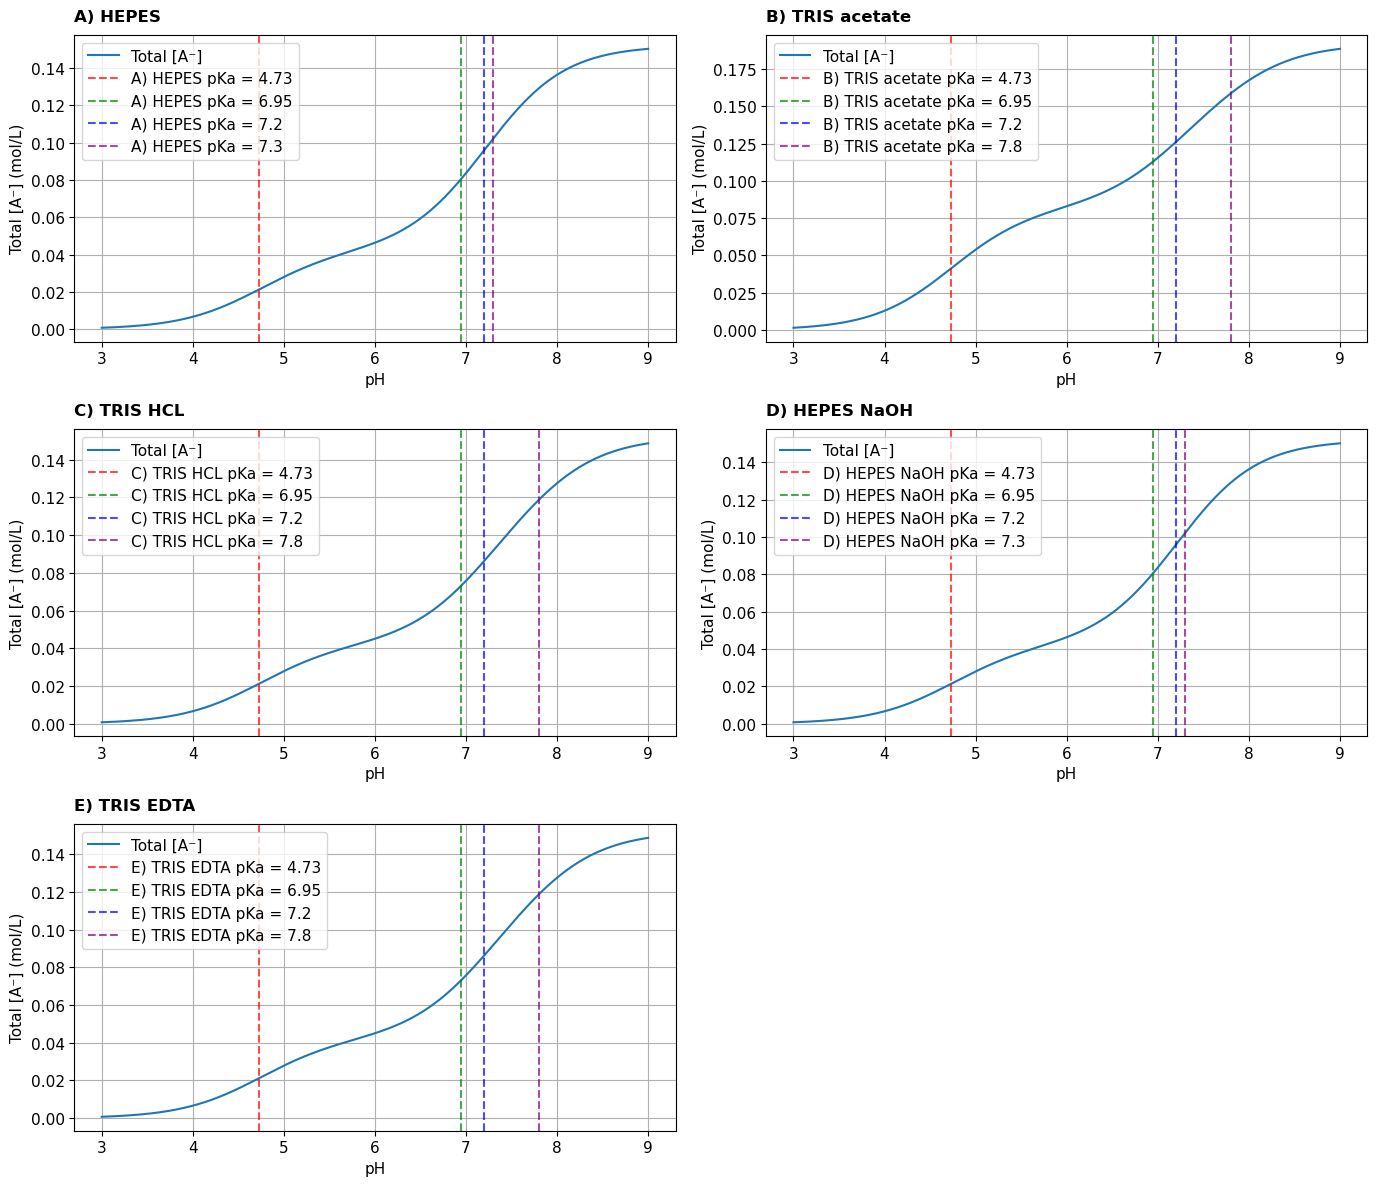

In [19]:
import numpy as np
import matplotlib.pyplot as plt
import math

def plot_buffer_systems(buffer_systems, pH_range=(3, 9), points=6000):

    pH_values = np.linspace(pH_range[0], pH_range[1], points)

    def total_base_conc(pH_vals, buffers):
        H = 10**(-pH_vals)
        total_A_minus = np.zeros_like(H)
        for pKa, conc in buffers:
            Ka = 10**(-pKa)
            A_minus = conc * Ka / (Ka + H)
            total_A_minus += A_minus
        return total_A_minus

    num_systems = len(buffer_systems)
    n_cols = 2
    n_rows = math.ceil(num_systems / n_cols)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4 * n_rows))
    axes = axes.flatten()

    for ax, (name, buffers) in zip(axes, buffer_systems):
        total_A = total_base_conc(pH_values, buffers)
        sorted_pKas = sorted(set([pKa for pKa, _ in buffers]))
        colormap = ['red', 'green', 'blue', 'purple', 'orange', 'cyan']
        color_cycle = (colormap * ((len(sorted_pKas) // len(colormap)) + 1))[:len(sorted_pKas)]
        color_map = dict(zip(sorted_pKas, color_cycle))
        
        ax.plot(pH_values, total_A, label='Total [A⁻]')
        # for pKa, _ in buffers:
        #     ax.axvline(pKa, linestyle='--', color=color_map[pKa], alpha=0.7, label=f'pKa = {pKa}')
       
        for pKa, _ in buffers:
            ax.axvline(pKa, linestyle='--', color=color_map[pKa], alpha=0.7, label=f'{name.strip()} pKa = {pKa}')

        
        plt.rcParams['font.size'] = '11'

        ax.set_title(name, loc='left', fontweight='bold', fontsize=12, pad=10)
        ax.set_xlabel('pH')
        ax.set_ylabel('Total [A⁻] (mol/L)')
        ax.grid(True)
        ax.legend()


    # Hide unused subplots if any
    for i in range(len(buffer_systems), len(axes)):
        fig.delaxes(axes[i])

    plt.tight_layout()
    # plt.savefig("buffer_systems_2cols.jpeg", dpi=750)
    plt.show()

# Example usage (same as before)
buffer_systems = [
    ("A) HEPES ", [(4.73, 0.042), (6.95, 0.01), (7.2, 0.06), (7.3, 0.04)]),
    ("B) TRIS acetate", [(4.73, 0.082), (6.95, 0.01), (7.2, 0.06), (7.8, 0.04)]),
    ("C) TRIS HCL", [(4.73, 0.042), (6.95, 0.01), (7.2, 0.06), (7.8, 0.04)]),
    ("D) HEPES NaOH", [(4.73, 0.042), (6.95, 0.01), (7.2, 0.06), (7.3, 0.04)]),
    ("E) TRIS EDTA", [(4.73, 0.042), (6.95, 0.01), (7.2, 0.06), (7.8, 0.04)])
]

plot_buffer_systems(buffer_systems)

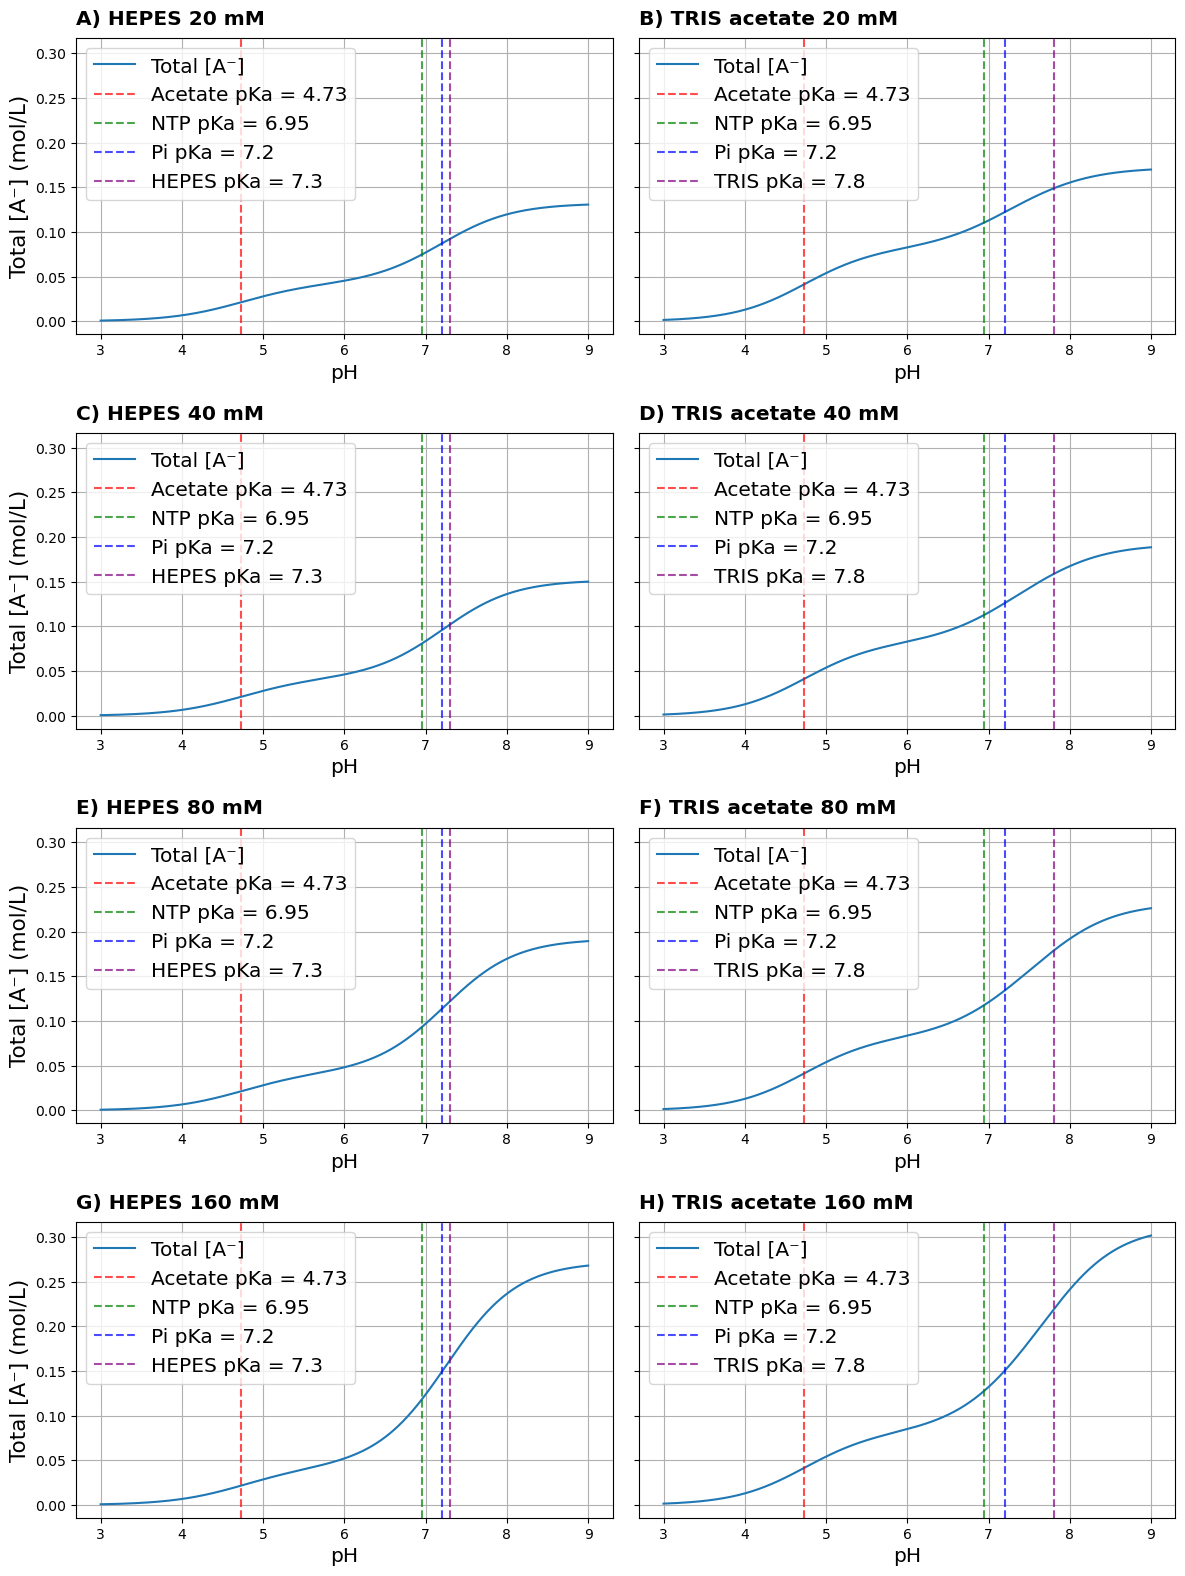

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import math

def plot_buffer_systems(buffer_systems, pH_range=(3, 9), points=6000):
    pH_values = np.linspace(pH_range[0], pH_range[1], points)

    def total_base_conc(pH_vals, buffers):
        H = 10**(-pH_vals)
        total_A_minus = np.zeros_like(H)
        for _, pKa, conc in buffers:
            Ka = 10**(-pKa)
            A_minus = conc * Ka / (Ka + H)
            total_A_minus += A_minus
        return total_A_minus

    num_systems = len(buffer_systems)
    cols = 2
    rows = math.ceil(num_systems / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(12, 4 * rows), sharey=True)
    axes = axes.flatten()

    colormap = ['red', 'green', 'blue', 'purple', 'orange', 'cyan']

    for ax, (name, buffers) in zip(axes, buffer_systems):
        total_A = total_base_conc(pH_values, buffers)
        ax.plot(pH_values, total_A, label='Total [A⁻]')

        sorted_pKas = sorted(set([pKa for _, pKa, _ in buffers]))
        color_cycle = (colormap * ((len(sorted_pKas) // len(colormap)) + 1))[:len(sorted_pKas)]
        color_map = dict(zip(sorted_pKas, color_cycle))

        plotted_labels = set()
        for comp_name, pKa, _ in buffers:
            label = f"{comp_name} pKa = {pKa}"
            if label not in plotted_labels:
                ax.axvline(pKa, linestyle='--', color=color_map[pKa], alpha=0.7, label=label)
                plotted_labels.add(label)
            else:
                ax.axvline(pKa, linestyle='--', color=color_map[pKa], alpha=0.7)

        plt.rcParams['font.size'] = '14.5'
        ax.set_title(name, loc='left', fontweight='bold', fontsize=14.5, pad=10)
        ax.set_xlabel('pH', fontsize=14.5),
        
        ax.grid(True)
        ax.legend()

    for i in range(0, len(axes), cols):
        axes[i].set_ylabel('Total [A⁻] (mol/L)', fontsize=15.5)

    for j in range(len(buffer_systems), len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    # plt.savefig('buffer_systems_subplots_2cols.jpeg')
    # plt.savefig('buffer_systems_subplots_2cols.jpeg', dpi=750)

    plt.savefig('buffer_systems_different_concentrations.pdf')

    plt.savefig('buffer_systems_different_concentrations.tif', dpi=600)
    
    plt.show()


buffer_systems = [
    ("A) HEPES 20 mM", [("Acetate", 4.73, 0.042), ("NTP", 6.95, 0.01), ("Pi", 7.2, 0.06), ("HEPES", 7.3, 0.02)]),
    ("B) TRIS acetate 20 mM", [("Acetate", 4.73, 0.082), ("NTP", 6.95, 0.01), ("Pi", 7.2, 0.06), ("TRIS", 7.8, 0.02)]),
    ("C) HEPES 40 mM", [("Acetate", 4.73, 0.042), ("NTP", 6.95, 0.01), ("Pi", 7.2, 0.06), ("HEPES", 7.3, 0.04)]),
    ("D) TRIS acetate 40 mM", [("Acetate", 4.73, 0.082), ("NTP", 6.95, 0.01), ("Pi", 7.2, 0.06), ("TRIS", 7.8, 0.04)]),
    ("E) HEPES 80 mM", [("Acetate", 4.73, 0.042), ("NTP", 6.95, 0.01), ("Pi", 7.2, 0.06), ("HEPES", 7.3, 0.08)]),
    ("F) TRIS acetate 80 mM", [("Acetate", 4.73, 0.082), ("NTP", 6.95, 0.01), ("Pi", 7.2, 0.06), ("TRIS", 7.8, 0.08)]),
    ("G) HEPES 160 mM", [("Acetate", 4.73, 0.042), ("NTP", 6.95, 0.01), ("Pi", 7.2, 0.06), ("HEPES", 7.3, 0.16)]),
    ("H) TRIS acetate 160 mM", [("Acetate", 4.73, 0.082), ("NTP", 6.95, 0.01), ("Pi", 7.2, 0.06), ("TRIS", 7.8, 0.16)])
]

plot_buffer_systems(buffer_systems)